# Wi-Fi CSI Simulation and Heatmap Visualization
This notebook simulates Wi-Fi Channel State Information (CSI) data for three different scenarios: **Still Room**, **Moving Room**, and **Jumping Room**. It then visualizes the simulated amplitude, phase, and RSSI metrics as heatmaps.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# --- Section 1: Simulate CSI Data Generation ---

def generate_synthetic_csi_data(num_packets, num_subcarriers, scenario_type="still"):
    """
    Generates synthetic CSI data mimicking the structure of the ESP32 output.

    Args:
        num_packets (int): Number of simulated Wi-Fi packets.
        num_subcarriers (int): Number of subcarriers per packet (e.g., 64 for 802.11n).
        scenario_type (str): "still", "moving", or "jumping" to influence data patterns.

    Returns:
        pd.DataFrame: A DataFrame containing simulated CSI data.
    """
    data_rows = []

    base_amplitude = 20 # General signal strength
    base_rssi = -45 # General RSSI

    for packet_idx in range(num_packets):
        # Simulate time progression for smoother changes
        time_factor = packet_idx / num_packets

        for subcarrier_idx in range(num_subcarriers):
            # Simulate slight subcarrier variations
            subcarrier_amplitude_offset = np.sin(subcarrier_idx * 0.5) * 2
            subcarrier_phase_offset = np.cos(subcarrier_idx * 0.3) * 0.5

            # Simulate scenario-specific changes
            if scenario_type == "still":
                # Small random noise for a "still" environment
                amplitude = base_amplitude + np.random.normal(0, 0.5) + subcarrier_amplitude_offset
                phase = np.random.uniform(-math.pi, math.pi) + np.random.normal(0, 0.05) + subcarrier_phase_offset
                rssi = base_rssi + np.random.normal(0, 1)
            elif scenario_type == "moving":
                # Gradual amplitude/phase changes over time
                amplitude = base_amplitude + np.sin(time_factor * np.pi * 4) * 5 + np.random.normal(0, 1) + subcarrier_amplitude_offset
                phase = np.sin(time_factor * np.pi * 8) * math.pi + np.random.normal(0, 0.1) + subcarrier_phase_offset
                rssi = base_rssi + np.sin(time_factor * np.pi * 2) * 5 + np.random.normal(0, 2)
            elif scenario_type == "jumping":
                # More abrupt, larger amplitude/phase changes at specific points
                amplitude = base_amplitude + np.sin(time_factor * np.pi * 12) * 8 + np.random.normal(0, 2) + subcarrier_amplitude_offset
                phase = np.sin(time_factor * np.pi * 20) * math.pi * 0.8 + np.random.normal(0, 0.2) + subcarrier_phase_offset
                rssi = base_rssi + np.cos(time_factor * np.pi * 10) * 10 + np.random.normal(0, 3)
            else: # Default or "still"
                amplitude = base_amplitude + np.random.normal(0, 0.5) + subcarrier_amplitude_offset
                phase = np.random.uniform(-math.pi, math.pi) + np.random.normal(0, 0.05) + subcarrier_phase_offset
                rssi = base_rssi + np.random.normal(0, 1)

            # Ensure phase stays within -pi to pi
            phase = math.atan2(math.sin(phase), math.cos(phase))

            data_rows.append({
                'SSID': "SimulatedNet",
                'SubCarrier_index': subcarrier_idx,
                'amplitude': amplitude,
                'phase': phase,
                'RSSI': rssi,
                'BSSID': "00:00:00:00:00:00"
            })

    return pd.DataFrame(data_rows)

# --- Visualization Function ---

def plot_csi_heatmaps(df, label):
    heatmap_metrics = ['amplitude', 'phase', 'RSSI']
    required_cols = ['SubCarrier_index'] + heatmap_metrics
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"Error: Missing columns in simulated data: {', '.join(missing_cols)}.")
        return

    n_subcarriers = df['SubCarrier_index'].max() + 1
    print(f"Inferred number of subcarriers per packet: {n_subcarriers}")

    if n_subcarriers == 0:
        print(f"Warning: No subcarrier data found. Skipping heatmaps.")
        return

    num_rows = len(df)
    num_complete_packets = num_rows // n_subcarriers

    if num_complete_packets == 0:
        print(f"Warning: Not enough data for at least one complete packet. Skipping.")
        return

    df_reshaped = df.iloc[:num_complete_packets * n_subcarriers]

    fig_hm, axes_hm = plt.subplots(len(heatmap_metrics), 1, figsize=(16, 6 * len(heatmap_metrics)), sharex=False)
    fig_hm.suptitle(f'Heatmaps for {label}', fontsize=20, fontweight='bold')

    if len(heatmap_metrics) == 1:
        axes_hm = [axes_hm]

    for j, metric in enumerate(heatmap_metrics):
        data_to_plot = df_reshaped[metric].values

        if data_to_plot.size == 0 or np.all(np.isnan(data_to_plot)):
            axes_hm[j].text(0.5, 0.5, f"No valid {metric} data found in '{label}' simulated data.",
                            horizontalalignment='center', verticalalignment='center',
                            transform=axes_hm[j].transAxes, color='orange', fontsize=14)
            continue

        reshaped_matrix = data_to_plot.reshape(num_complete_packets, n_subcarriers)

        if metric == 'phase':
            vmin, vmax = -math.pi, math.pi
            cmap = 'twilight'
        elif metric == 'amplitude':
            vmin, vmax = None, None
            cmap = 'viridis'
        elif metric == 'RSSI':
            vmin, vmax = -100, -30
            cmap = 'hot'
        else:
            vmin, vmax = None, None
            cmap = 'viridis'

        im = axes_hm[j].imshow(reshaped_matrix, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                                extent=[0, n_subcarriers, num_complete_packets, 0])

        display_metric_name = metric.capitalize() if metric != 'RSSI' else metric
        axes_hm[j].set_title(f'{label} - {display_metric_name} Heatmap', fontsize=16)
        axes_hm[j].set_xlabel('Subcarrier Index', fontsize=12)
        axes_hm[j].set_ylabel('Packet Index', fontsize=12)

        cbar = fig_hm.colorbar(im, ax=axes_hm[j])
        cbar.set_label(f'{display_metric_name} Value', fontsize=12)

        if num_complete_packets > 10:
             axes_hm[j].set_yticks(np.linspace(0, num_complete_packets, min(5, num_complete_packets // 10 + 2)).astype(int))

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

# --- Common Simulation Parameters ---
num_simulated_packets = 200
num_simulated_subcarriers = 52

## Scenario 1: Simulated Still Room
In this scenario, the environment is static. The CSI data will show only minor random noise over time.

--- Processing Simulated Still Room (Simulated Data) ---
DataFrame head:
           SSID  SubCarrier_index  amplitude     phase       RSSI  \
0  SimulatedNet                 0  19.710832 -2.804771 -45.382497   
1  SimulatedNet                 1  21.100649  0.638669 -45.144591   
2  SimulatedNet                 2  21.871616 -1.758439 -44.558504   
3  SimulatedNet                 3  20.318412  3.118710 -45.157431   
4  SimulatedNet                 4  22.533320  3.065969 -44.944413   

               BSSID  
0  00:00:00:00:00:00  
1  00:00:00:00:00:00  
2  00:00:00:00:00:00  
3  00:00:00:00:00:00  
4  00:00:00:00:00:00  

DataFrame info:
---------------------------------------
Inferred number of subcarriers per packet: 52


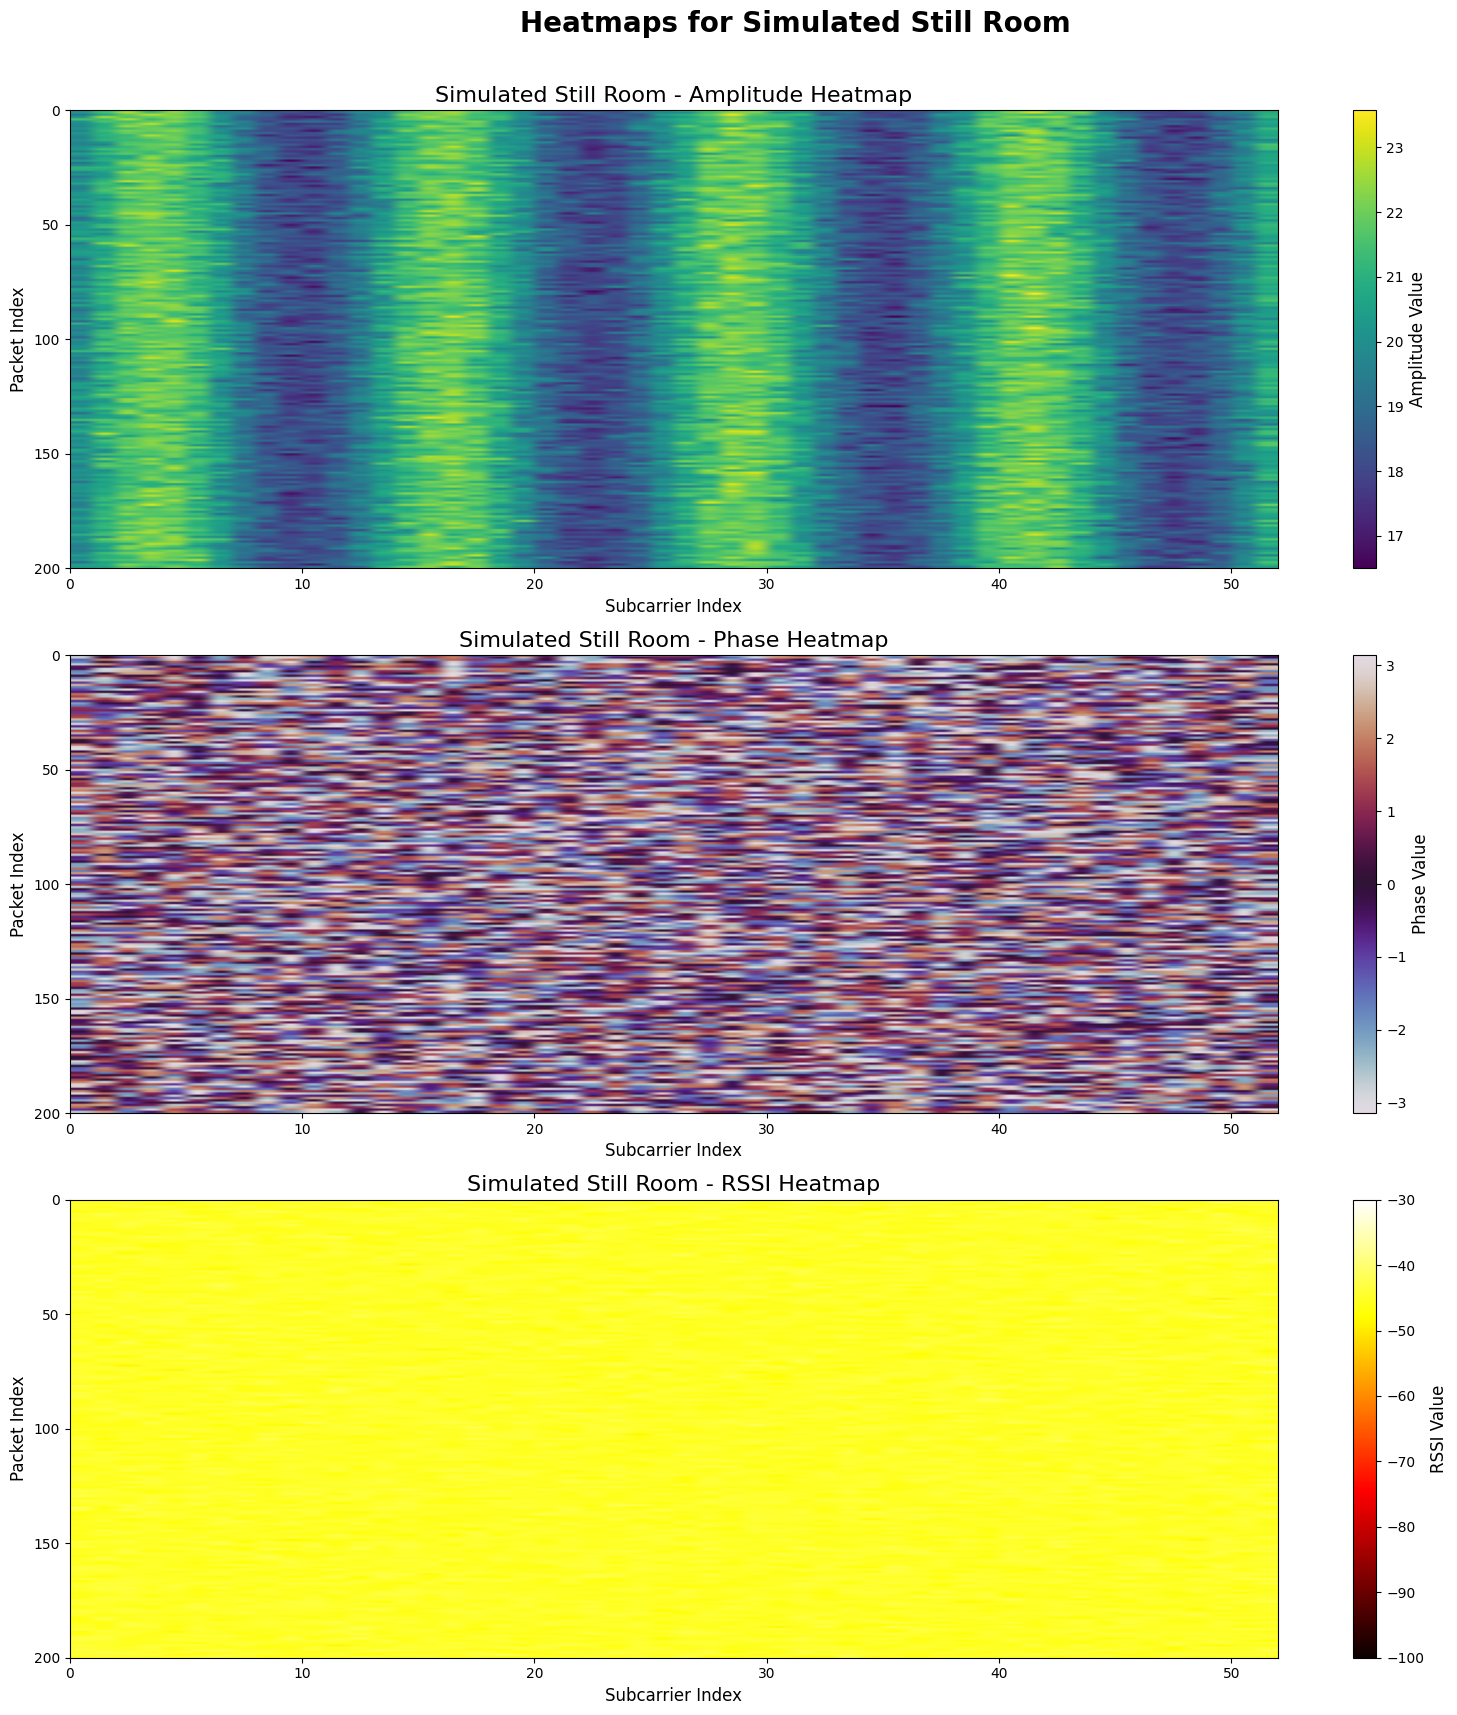

In [4]:
print("--- Processing Simulated Still Room (Simulated Data) ---")
df_still = generate_synthetic_csi_data(num_simulated_packets, num_simulated_subcarriers, "still")

# Debugging Prints
print("DataFrame head:")
print(df_still.head())
print("---------------------------------------")

# Plot Heatmaps
plot_csi_heatmaps(df_still, "Simulated Still Room")

## Scenario 2: Simulated Moving Room
In this scenario, movement is occurring gradually in the environment. This results in periodic sinusoidal changes in both amplitude and phase over time.

--- Processing Simulated Moving Room (Simulated Data) ---
DataFrame head:
           SSID  SubCarrier_index  amplitude     phase       RSSI  \
0  SimulatedNet                 0  21.426413  0.414373 -44.792533   
1  SimulatedNet                 1  21.781262  0.448124 -43.998288   
2  SimulatedNet                 2  20.656723  0.381351 -45.884332   
3  SimulatedNet                 3  21.403222  0.320784 -42.753288   
4  SimulatedNet                 4  21.569796  0.059518 -43.937175   

               BSSID  
0  00:00:00:00:00:00  
1  00:00:00:00:00:00  
2  00:00:00:00:00:00  
3  00:00:00:00:00:00  
4  00:00:00:00:00:00  

DataFrame info:
---------------------------------------
Inferred number of subcarriers per packet: 52


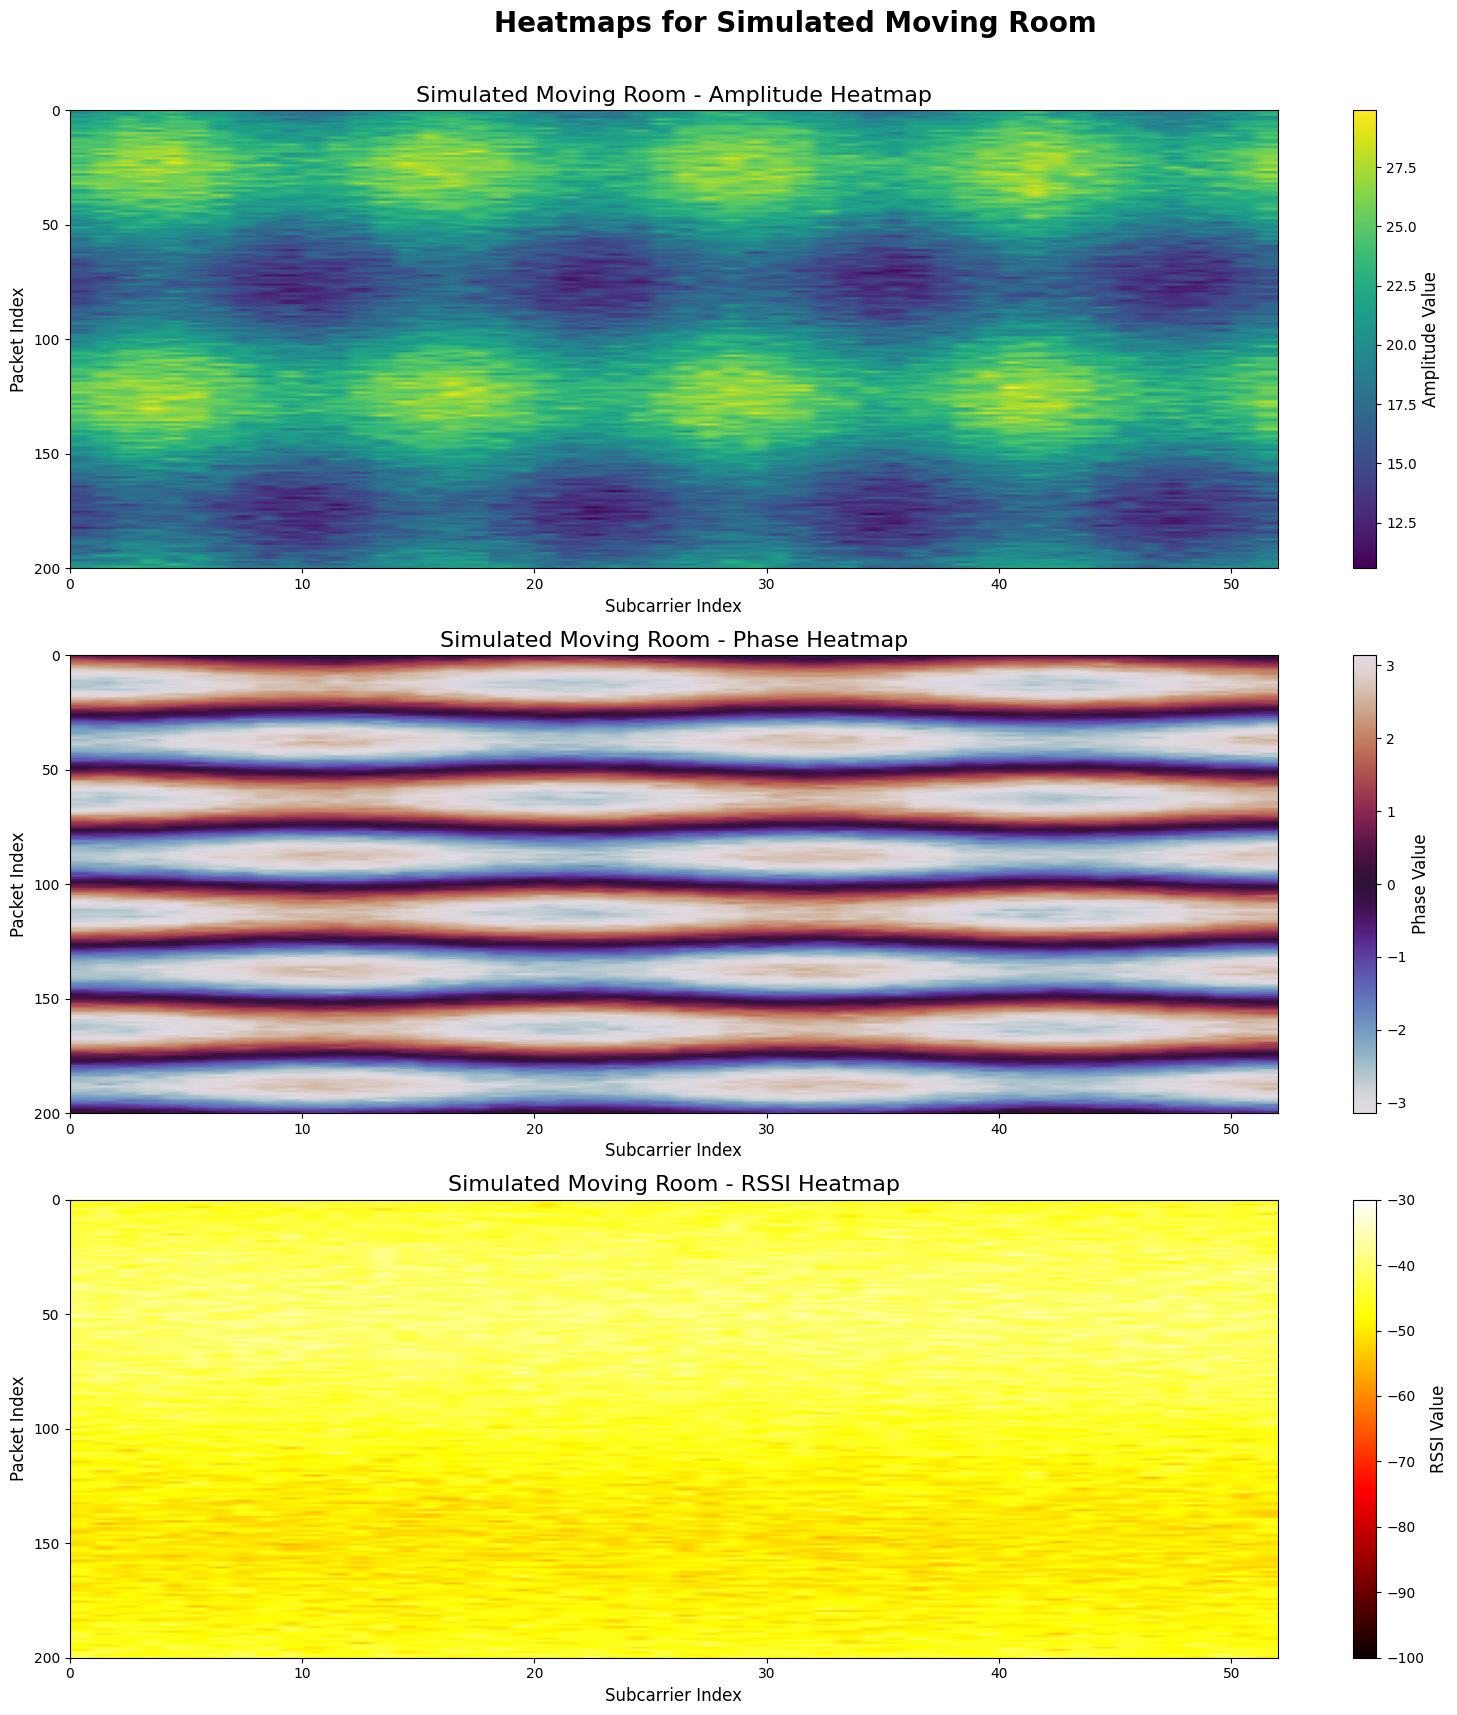

In [6]:
print("--- Processing Simulated Moving Room (Simulated Data) ---")
df_moving = generate_synthetic_csi_data(num_simulated_packets, num_simulated_subcarriers, "moving")

# Debugging Prints
print("DataFrame head:")
print(df_moving.head())
print("\nDataFrame info:")
# df_moving.info()
print("---------------------------------------")

# Plot Heatmaps
plot_csi_heatmaps(df_moving, "Simulated Moving Room")

## Scenario 3: Simulated Jumping Room
In this scenario, abrupt and rapid motions (like jumping) occur. This causes higher-frequency, larger-amplitude fluctuations in amplitude, phase, and RSSI.

--- Processing Simulated Jumping Room (Simulated Data) ---
DataFrame head:
           SSID  SubCarrier_index  amplitude     phase       RSSI  \
0  SimulatedNet                 0  18.602531  0.756719 -35.779121   
1  SimulatedNet                 1  24.771606  0.552038 -36.740759   
2  SimulatedNet                 2  17.560721  0.739240 -40.703038   
3  SimulatedNet                 3  21.406650  0.536561 -31.713574   
4  SimulatedNet                 4  22.485330  0.078408 -35.229016   

               BSSID  
0  00:00:00:00:00:00  
1  00:00:00:00:00:00  
2  00:00:00:00:00:00  
3  00:00:00:00:00:00  
4  00:00:00:00:00:00  

DataFrame info:
---------------------------------------
Inferred number of subcarriers per packet: 52


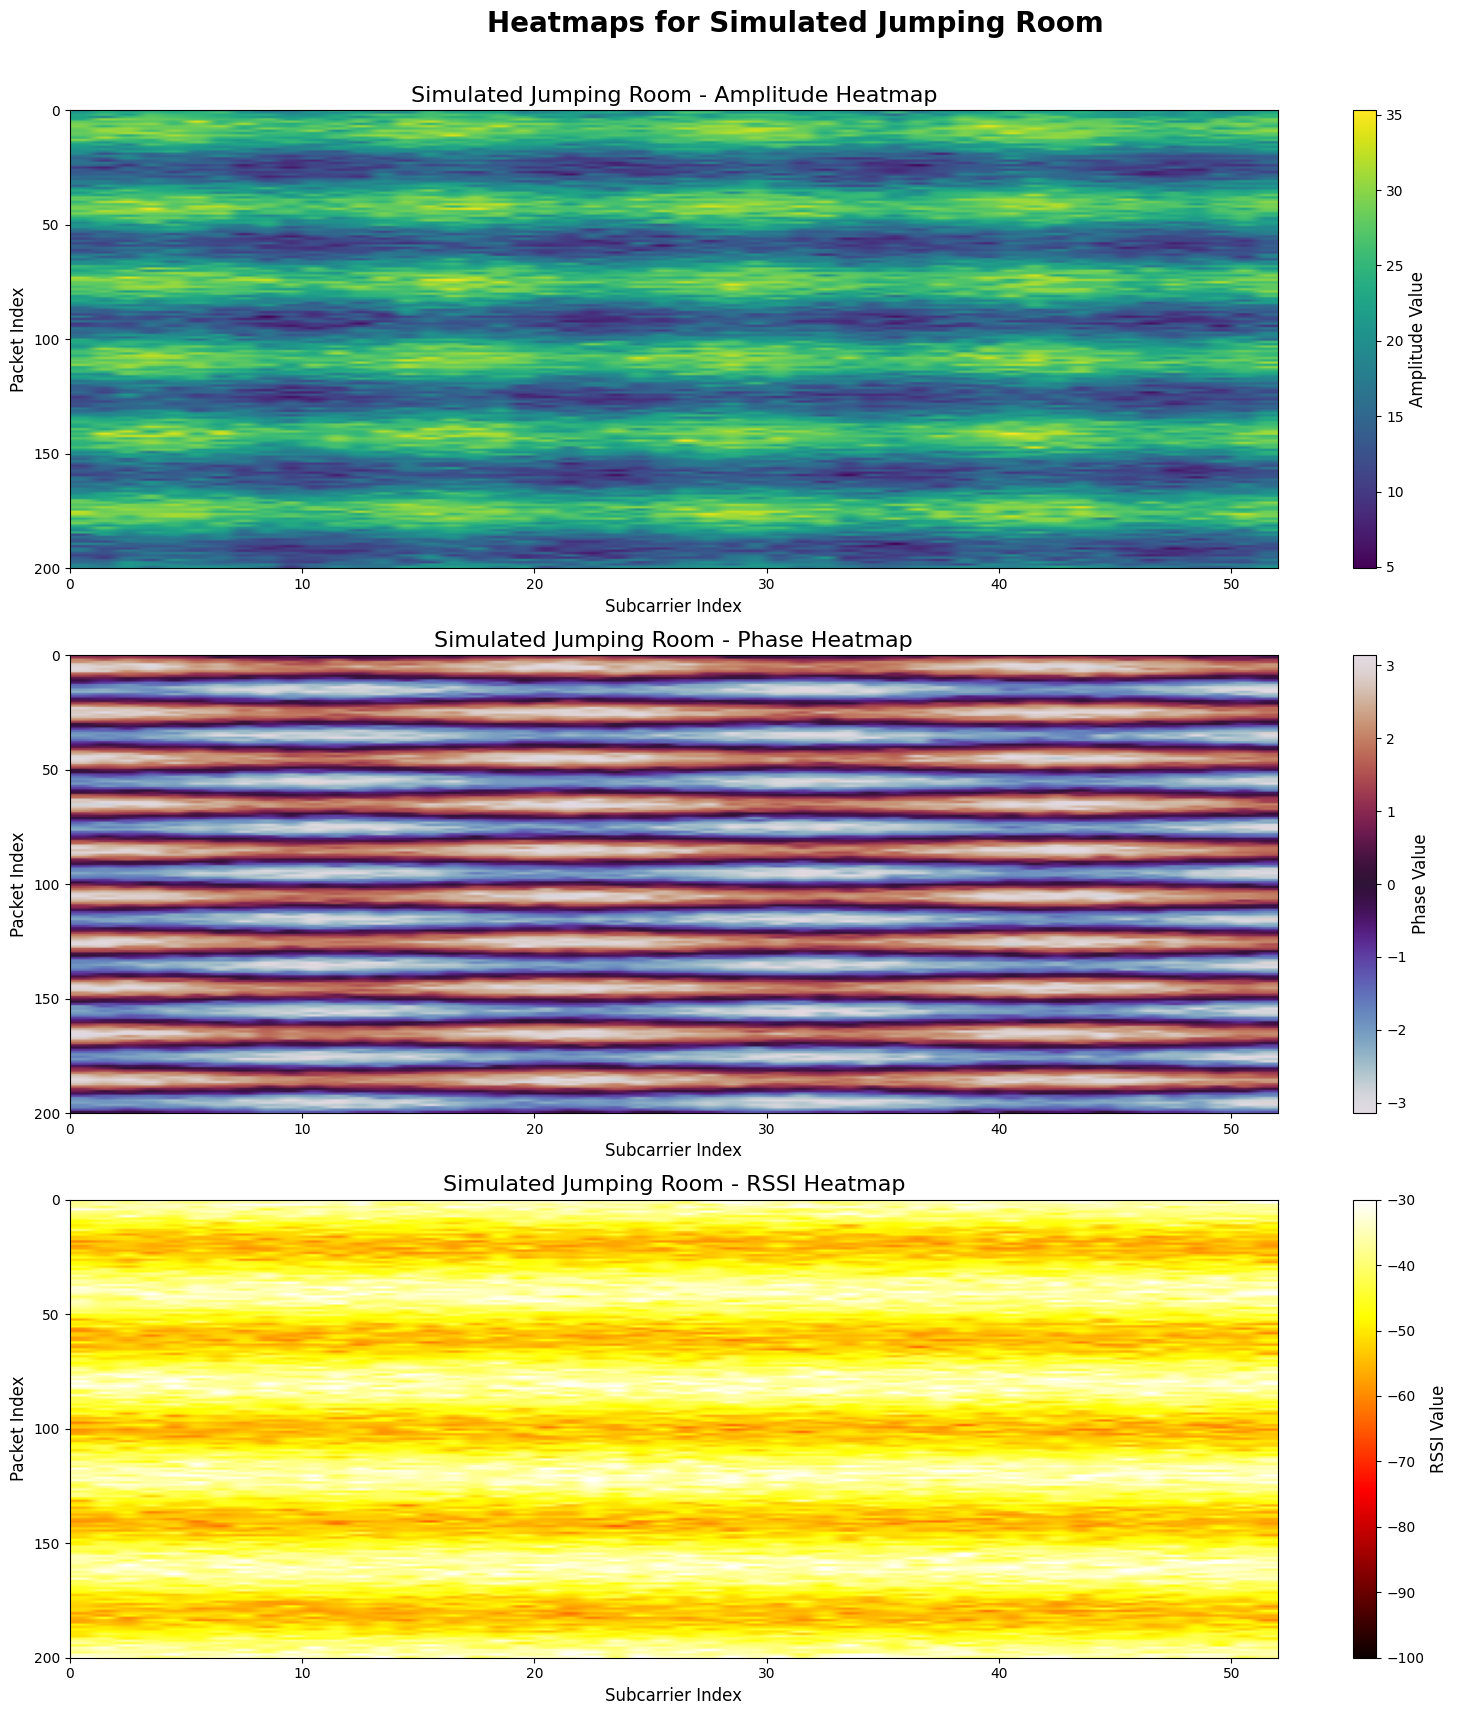

In [7]:
print("--- Processing Simulated Jumping Room (Simulated Data) ---")
df_jumping = generate_synthetic_csi_data(num_simulated_packets, num_simulated_subcarriers, "jumping")

# Debugging Prints
print("DataFrame head:")
print(df_jumping.head())
print("\nDataFrame info:")
# df_jumping.info()
print("---------------------------------------")

# Plot Heatmaps
plot_csi_heatmaps(df_jumping, "Simulated Jumping Room")

## Simulated Heatmap Interpretation Notes
These heatmaps visualize synthetic CSI metrics over simulated time and subcarriers.
- **X-axis (Subcarrier Index):** Represents individual Wi-Fi subcarriers.
- **Y-axis (Packet Index):** Represents the sequence of simulated Wi-Fi packets/CSI measurements over time.
- **Color:** Indicates the value of the respective metric.

Since this data is simulated, the patterns (e.g., 'moving' vs. 'still') are generated artificially to demonstrate how CSI data might look under different conditions. Real-world CSI data would capture actual environmental interactions.